In [1]:
import os
import sys
sys.path.insert(0,os.path.abspath('../src/'))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

from topo_edit_util import map_mask, mom6_latlon2ij


In [3]:
path_old = '/glade/work/bryan/MOM6-data-files/Topography/tx2_3v2/'
#file_old = 'topo.sub150.tx2_3v2.srtm.nc'
file_old = 'topo.sub150.tx2_3v2.srtm.edit4.SmL1.0_C1.0.nc'
df_old = xr.open_dataset(path_old+file_old)
df_old

<xarray.Dataset> Size: 20MB
Dimensions:     (lath: 480, lonh: 540, latq: 481, lonq: 541)
Coordinates:
  * lath        (lath) float64 4kB -81.56 -81.46 -81.36 ... 89.33 89.6 89.86
  * lonh        (lonh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * latq        (latq) float64 4kB -81.61 -81.51 -81.41 ... 89.46 89.72 89.91
  * lonq        (lonq) float64 4kB -287.0 -286.3 -285.7 ... 71.67 72.33 73.0
Data variables: (12/15)
    geolon      (lath, lonh) float64 2MB ...
    geolat      (lath, lonh) float64 2MB ...
    geolonb     (latq, lonq) float64 2MB ...
    geolatb     (latq, lonq) float64 2MB ...
    z           (lath, lonh) float32 1MB ...
    ocn_frac    (lath, lonh) float32 1MB ...
    ...          ...
    D2_mean     (lath, lonh) float32 1MB ...
    D_min       (lath, lonh) float32 1MB ...
    D_max       (lath, lonh) float32 1MB ...
    hand_edits  (lath, lonh) int32 1MB ...
    orig_mask   (lath, lonh) int32 1MB ...
    D_interp    (lath, lonh) float32 1MB ...
Attributes:
    Description:             Ocean Topography Statistics on MOM6 Grid
    Creator:                 Frank Bryan
    Created:                 20221228
    Generating Code:         create_model_topo.f90
    Model Grid Version:      tx2_3v2
    Source Topography Data:  /glade/work/bryan/Observations/Topography/SRTM/S...
    Edit History:            Hand Edit + Lake Fill 04/04/2023

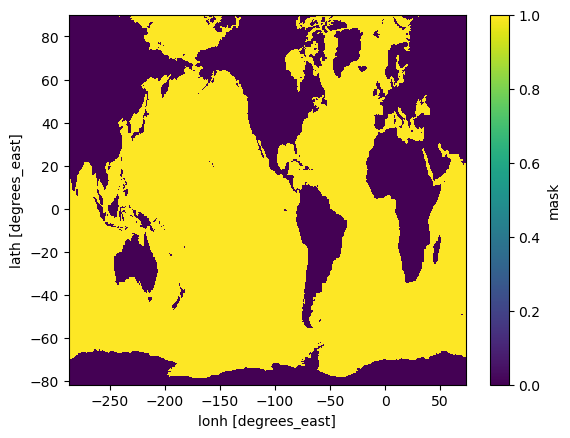

In [4]:
df_old['mask'].plot()

In [5]:
path_new = '/glade/derecho/scratch/bryan/tx2_3v3_Feb2026/'
file_new = 'topo.sub150.tx2_3v3.SRTM15_V2.4.edit1.nc'
df_new = xr.open_dataset(path_new+file_new)

In [6]:
df_new

<xarray.Dataset> Size: 19MB
Dimensions:     (lath: 480, lonh: 540, latq: 481, lonq: 541)
Coordinates:
  * lath        (lath) float64 4kB -81.56 -81.46 -81.36 ... 89.33 89.6 89.86
  * lonh        (lonh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * latq        (latq) float64 4kB -81.61 -81.51 -81.41 ... 89.46 89.72 89.91
  * lonq        (lonq) float64 4kB -287.0 -286.3 -285.7 ... 71.67 72.33 73.0
Data variables: (12/14)
    geolon      (lath, lonh) float64 2MB ...
    geolat      (lath, lonh) float64 2MB ...
    geolonb     (latq, lonq) float64 2MB ...
    geolatb     (latq, lonq) float64 2MB ...
    z           (lath, lonh) float32 1MB ...
    ocn_frac    (lath, lonh) float32 1MB ...
    ...          ...
    D_median    (lath, lonh) float32 1MB ...
    D2_mean     (lath, lonh) float32 1MB ...
    D_min       (lath, lonh) float32 1MB ...
    D_max       (lath, lonh) float32 1MB ...
    hand_edits  (lath, lonh) int32 1MB ...
    orig_mask   (lath, lonh) int32 1MB ...
Attributes:
    Description:             Ocean Topography Statistics on MOM6 Grid
    Creator:                 Frank Bryan
    Created:                 20260225
    Generating Code:         create_model_topo.f90
    Model Grid Version:      tx2_3v3
    Source Topography Data:  /glade/work/bryan/Observations/Topography/SRTM/S...
    Edit History:            Hand Edit + Lake Fill 02/25/2026

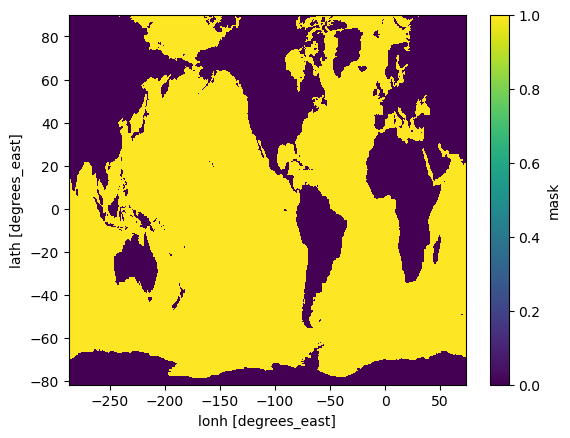

In [7]:
df_new['mask'].plot()

In [8]:
np.max(np.abs((df_old['geolat'].values - df_new['geolat'].values)))

np.float64(0.0)

In [9]:
np.max(np.abs((df_old['geolon'].values - df_new['geolon'].values)))

np.float64(0.0)

In [10]:
np.max(np.abs((df_old['mask'] - df_new['mask']).values))

np.int32(1)

In [19]:
np.abs((df_old['mask'] - df_new['mask']).values).sum()

np.int64(38)

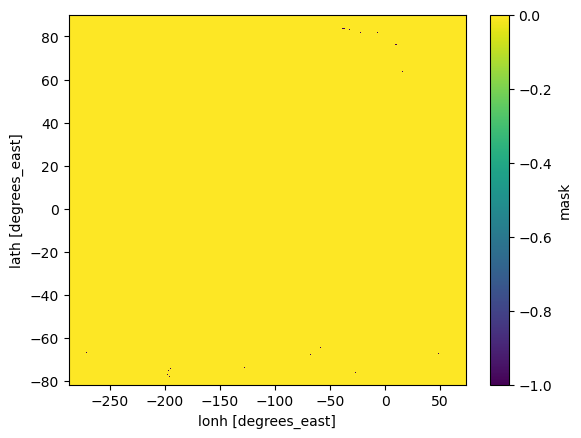

In [11]:
(df_new['mask'] - df_old['mask']).plot()

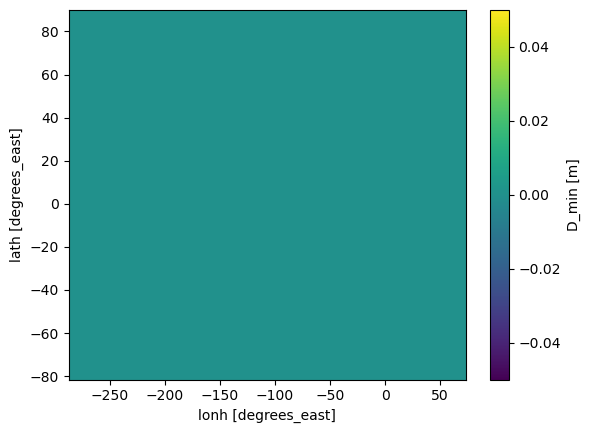

In [12]:
(df_new['D_min'] - df_old['D_min']).plot()

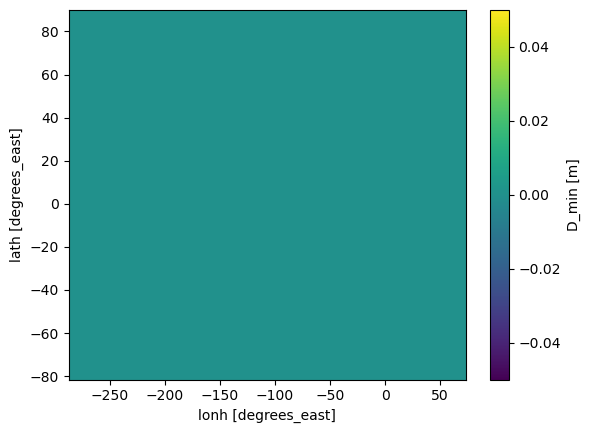

In [13]:
(df_new['D_min'] - df_old['D_min']).plot()

<xarray.DataArray 'D_mean' ()> Size: 8B
array(0.)
Attributes:
    longname:  mean ocean depth in cell
    units:     meters

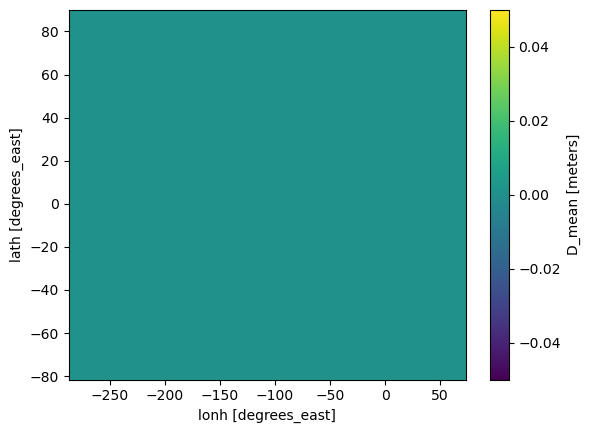

In [18]:
(df_new['D_mean'] - df_old['D_mean']).plot()
np.max(np.abs((df_new['D_mean'] - df_old['D_mean'])))

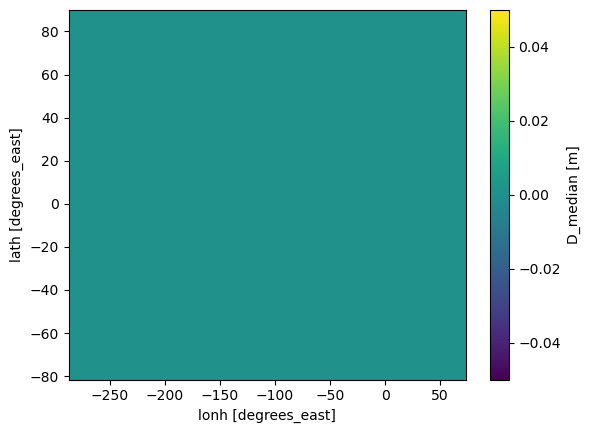

In [15]:
(df_new['D_median'] - df_old['D_median']).plot()

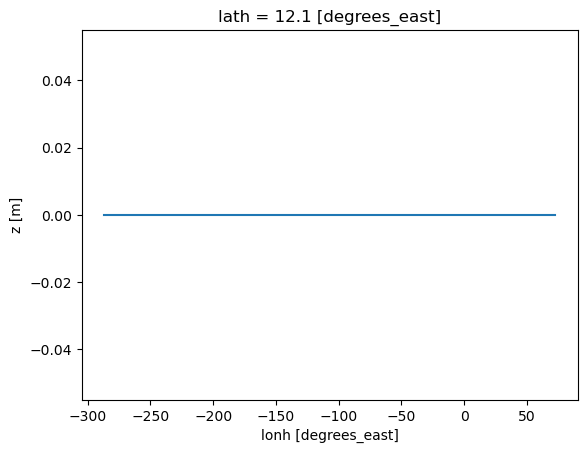

In [16]:
(df_new['z'] - df_old['z']).isel(lath=300).plot()

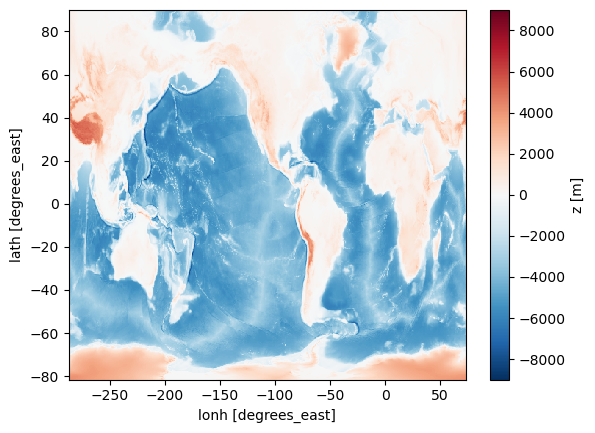

In [17]:
df_old['z'].plot()